## Procesamiento de Imágenes - Diplodatos 2025

Trabajo Práctico

Importante: Para obtener los créditos de materia completa, resolver al menos 1 ejercicio optativo de cada trabajo práctico.

In [1]:
integrantes = ["Campilongo, Javier", "Delfino, Facundo", "Saker, Leila"]
print(*integrantes, sep="\n")


Campilongo, Javier
Delfino, Facundo
Saker, Leila


Importar las librerías necesarias

In [2]:
import imageio
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

Abrir imágenes de demo incluídas en la biblioteca. Para evitar cargar desde disco, pueden utilizar estas imágenes para resolver el TP. Si utilizan otras adjuntarlas en la entrega para reproducibilidad.

/tmp/ipython-input-2218414591.py:1: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  img = imageio.imread('imageio:wikkie.png')


Imageio: 'wikkie.png' was not found on your computer; downloading it now.
Try 1. Download from https://github.com/imageio/imageio-binaries/raw/master/images/wikkie.png (461 kB)
Downloading: 8192/472047 bytes (1.7%)472047/472047 bytes (100.0%)
  Done
File saved as /root/.imageio/images/wikkie.png.


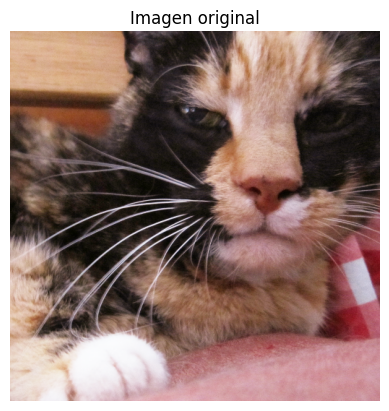

In [3]:
img = imageio.imread('imageio:wikkie.png')
img_norm = img / 255.0  # normalizamos a [0,1]
plt.imshow(img)
plt.title("Imagen original")
plt.axis('off')
plt.show()
# Otras imágenes (extraído de la documentación de imageio)

# bricks.jpg: A (repeatable) texture of stone bricks
# wood.jpg: A (repeatable) texture of wooden planks
# astronaut.png: Image of the astronaut Eileen Collins
# camera.png: A grayscale image of a photographer
# checkerboard.png: Black and white image of a chekerboard
# chelsea.png: Image of Stefan’s cat
# clock.png: Photo of a clock with motion blur (Stefan van der Walt)
# coffee.png: Image of a cup of coffee (Rachel Michetti)
# coins.png: Image showing greek coins from Pompeii
# horse.png: Image showing the silhouette of a horse (Andreas Preuss)
# hubble_deep_field.png: Photograph taken by Hubble telescope (NASA)
# immunohistochemistry.png: Immunohistochemical (IHC) staining
# moon.png: Image showing a portion of the surface of the moon
# page.png: A scanned page of text
# text.png: A photograph of handdrawn text
# wikkie.png: Image of Almar’s cat

# Ejercicio 1.1
La propuesta para esta actividad consiste en manipular independientemente la luminancia y la saturación de una imagen.
Para ello convertimos cada pixel de la imagen del espacio RGB al espacio YIQ, luego alteramos los valores de Y (para cambiar la luminancia) o de IQ (para cambiar la saturación).
Con los nuevos valores de YIQ, convertimos a RGB nuevamente y obtenemos una nueva imagen.

In [4]:
# Definimos las matrices de conversión RGB <-> YIQ
RGB_to_YIQ = np.array([
    [0.299,  0.587,  0.114],
    [0.596, -0.275, -0.321],
    [0.212, -0.523,  0.311]
])

YIQ_to_RGB = np.linalg.inv(RGB_to_YIQ)

# Convertimos de RGB a YIQ
def apply_matrix(img, M):
    return np.matmul( img.reshape((-1,3)), M.T ).reshape(img.shape)
img_YIQ = apply_matrix(img_norm, RGB_to_YIQ)

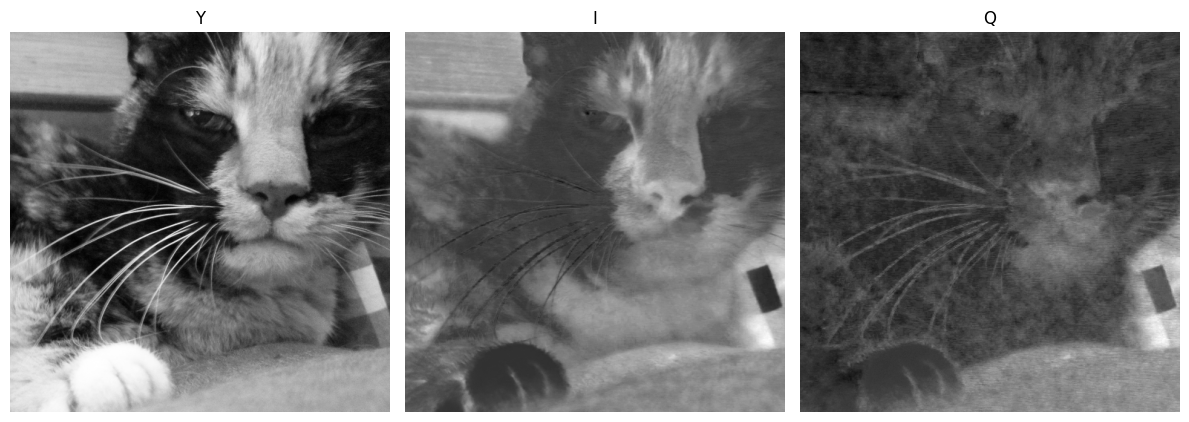

In [5]:
# Separamos canales Y, I, Q de la imagen original
Y = img_YIQ[..., 0]
I = img_YIQ[..., 1]
Q = img_YIQ[..., 2]

# Visualizamos en escala de grises cada componente
plt.figure(figsize=(12, 6))

plt.subplot(1, 3, 1)
plt.title('Y')
plt.imshow(Y, cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title('I')
plt.imshow(I, cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title('Q')
plt.imshow(Q, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()

In [6]:
from ipywidgets import interact, FloatSlider
from IPython.display import display

# Función para modificar luminancia y saturación
def modify_luminance_saturation(img_YIQ, luminance_factor, saturation_factor):
    Y = img_YIQ[..., 0] * luminance_factor
    I = img_YIQ[..., 1] * saturation_factor
    Q = img_YIQ[..., 2] * saturation_factor

  # Recombinar los canales modificados
    img_YIQ_mod = np.stack((Y, I, Q), axis=-1)

  # Convertir de YIQ a RGB
    img_RGB_mod = apply_matrix(img_YIQ_mod, YIQ_to_RGB)

  # Asegurar que los valores RGB estén en el rango [0, 1]
    img_RGB_mod = np.clip(img_RGB_mod, 0, 1)
    return img_RGB_mod

# Función interactiva para modificar luminancia y saturación, y comparar con la original
def interactive_luminance_saturation(luminance_factor, saturation_factor):
    img_modified = modify_luminance_saturation(img_YIQ, luminance_factor, saturation_factor)

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))

    axes[0].imshow(img_norm)
    axes[0].set_title("Imagen original")
    axes[0].axis('off')

    axes[1].imshow(img_modified)
    axes[1].set_title(f"Y={luminance_factor:.2f}, IQ={saturation_factor:.2f}")
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()

# 7. Sliders interactivos
luminance_slider = FloatSlider(min=0.1, max=2.0, step=0.05, value=1.0, description='Y:')
saturation_slider = FloatSlider(min=0.0, max=2.0, step=0.05, value=1.0, description='IQ:')

print("Ajusta los sliders para modificar la luminancia (Y) y la saturación (IQ) de la imagen:")
interact(interactive_luminance_saturation,
         luminance_factor=luminance_slider,
         saturation_factor=saturation_slider);

Ajusta los sliders para modificar la luminancia (Y) y la saturación (IQ) de la imagen:


interactive(children=(FloatSlider(value=1.0, description='Y:', max=2.0, min=0.1, step=0.05), FloatSlider(value…

# **CONCLUSIÓN**

Luminancia (Y):

*   Si bajamos la luminancia, en la imagen se puede ver que todo se oscurece, y los detalles en las zonas claras se hacen menos visibles.

*   Si subimos la luminancia, la imagen se aclara, los colores se ven más brillantes y los detalles en las zonas oscuras se destacan más.

Saturación (I y Q):

*   Si bajamos la saturación, los colores de la imagen se vuelven más apagados, acercándose a una escala de grises.

*   Si subimos la saturación, los colores se vuelven más vivos e intensos, aumentando el contraste visual entre tonos, aunque genera colores poco naturales o muy saturados.

# Ejercicio 1.2
Desarrollar un aplicativo o notebook que pueda abrir una imagen, manipule su histograma de luminancias, y luego ver la imagen procesada. Se debe poder elegir filtro raíz, cuadrado, o lineal a trozos.
Los controles para elegir los filtros los organizan como les resulte más cómodo.

In [ ]:
from ipywidgets import interact, Dropdown


# Función de procesamiento de luminancia (filtros)
def process_luminance(Y, filter_type):
    if filter_type == 'Raíz':
        Y_new = np.sqrt(Y)
    elif filter_type == 'Cuadrado':
        Y_new = Y**2
    elif filter_type == 'Lineal a trozos':
        Y_new = np.zeros_like(Y)
        mask1 = Y <= 0.33
        mask2 = (Y > 0.33) & (Y <= 0.66)
        mask3 = Y > 0.66
        Y_new[mask1] = Y[mask1] * 0.5
        Y_new[mask2] = 0.25 + (Y[mask2]-0.33) * 1.5
        Y_new[mask3] = 0.75 + (Y[mask3]-0.66) * 0.9
        Y_new = np.clip(Y_new, 0, 1)
    else:
        Y_new = Y
    return Y_new

# Función interactiva para histogramas
def interactive_luminance_histogram(filter_type):
    Y = img_YIQ[..., 0]  # Luminancia original
    Y_new = process_luminance(Y, filter_type)  # Luminancia filtrada

    plt.figure(figsize=(12,5))

    plt.subplot(1,2,1)
    plt.hist(Y.ravel(), bins=256, color='purple')
    plt.title("Histograma Y original")
    plt.xlabel("Intensidad")
    plt.ylabel("Número de píxeles")

    plt.subplot(1,2,2)
    plt.hist(Y_new.ravel(), bins=256, color='purple')
    plt.title(f"Histograma Y filtrado ({filter_type})")
    plt.xlabel("Intensidad")
    plt.ylabel("Número de píxeles")

    plt.tight_layout()
    plt.show()

# Dropdown interactivo para seleccionar filtro
filter_dropdown_hist = Dropdown(
    options=['Raíz', 'Cuadrado', 'Lineal a trozos'],
    description='Filtro:'
)

print("Selecciona un filtro para ver el histograma de luminancia:")
interact(interactive_luminance_histogram, filter_type=filter_dropdown_hist)

Selecciona un filtro para ver el histograma de luminancia:


interactive(children=(Dropdown(description='Filtro:', options=('Raíz', 'Cuadrado', 'Lineal a trozos'), value='…

<function __main__.interactive_luminance_histogram(filter_type)>

In [ ]:
# Función para mostrar la imagen procesada junto con la original
def interactive_luminance_image(filter_type):
    Y = img_YIQ[..., 0]
    I = img_YIQ[..., 1]
    Q = img_YIQ[..., 2]

    # Aplicar filtro a Y
    Y_new = process_luminance(Y, filter_type)

    # Recombinamos Y con I y Q y convertimos a RGB
    img_YIQ_mod = np.stack((Y_new, I, Q), axis=-1)
    img_RGB_mod = apply_matrix(img_YIQ_mod, YIQ_to_RGB)
    img_RGB_mod = np.clip(img_RGB_mod, 0, 1)

    # Mostrar imágenes
    plt.figure(figsize=(12,6))

    # Imagen original
    plt.subplot(1,2,1)
    plt.imshow(img_norm)
    plt.title("Imagen original")
    plt.axis('off')

    # Imagen procesada
    plt.subplot(1,2,2)
    plt.imshow(img_RGB_mod)
    plt.title(f"Imagen filtrada ({filter_type})")
    plt.axis('off')

    plt.tight_layout()
    plt.show()

# Dropdown interactivo para seleccionar filtro
filter_dropdown_img = Dropdown(
    options=['Raíz', 'Cuadrado', 'Lineal a trozos'],
    description='Filtro:'
)

print("Selecciona un filtro para ver la imagen original y la procesada:")
interact(interactive_luminance_image, filter_type=filter_dropdown_img)


Selecciona un filtro para ver la imagen original y la procesada:


interactive(children=(Dropdown(description='Filtro:', options=('Raíz', 'Cuadrado', 'Lineal a trozos'), value='…

<function __main__.interactive_luminance_image(filter_type)>

# **Ejercicio 1.3 (optativo)**
La propuesta para esta actividad consiste en utilizar algunos datasets 2D (pueden ser mapas de altitud, de temperatura, etc.) y “visualizarlos” con diferentes paletas, incluyendo la de niveles de gris y la arco iris.

In [7]:
import os
import matplotlib as mpl
import matplotlib.cbook as cbook

# We will not rely on mpl.get_data_path() directly due to previous errors.
# Instead, we will generate a synthetic dataset in the next cell.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from ipywidgets import interact, Dropdown

# 1. Generar un dataset 2D de muestra sintético (por ejemplo, un patrón de onda)
x = np.linspace(-5, 5, 200)
y = np.linspace(-5, 5, 200)
X, Y = np.meshgrid(x, y)
img_synthetic = np.sin(np.sqrt(X**2 + Y**2)) # Genera un patrón de onda circular

# 2. Normalizar si es necesario a [0,1]
# En este caso, np.sin ya produce valores entre -1 y 1, así que los normalizamos a [0,1]
img_norm = (img_synthetic - img_synthetic.min()) / (img_synthetic.max() - img_synthetic.min())

# 3. Definir paletas de colores (colormaps)
colormaps = {
    "Gris": "gray",
    "Arco Iris": "rainbow",
    "Viridis": "viridis",
    "Plasma": "plasma",
    "Terreno": "terrain",
    "Magma": "magma"
}

# 4. Función para visualizar con colormap seleccionado
def interactive_colormap(cmap_name):
    cmap = colormaps[cmap_name]
    plt.figure(figsize=(8,6))
    im = plt.imshow(img_norm, cmap=cmap, origin='lower')
    plt.title(f"Dataset Sintético con colormap: {cmap_name}")
    plt.axis('off')
    plt.colorbar(im, fraction=0.046, pad=0.04)
    plt.show()

# 5. Dropdown interactivo para elegir colormap
dropdown = Dropdown(
    options=list(colormaps.keys()),
    description='Paleta:'
)

print("Selecciona una paleta de colores para visualizar el dataset:")
interact(interactive_colormap, cmap_name=dropdown)


Selecciona una paleta de colores para visualizar el dataset:


interactive(children=(Dropdown(description='Paleta:', options=('Gris', 'Arco Iris', 'Viridis', 'Plasma', 'Terr…

<function __main__.interactive_colormap(cmap_name)>

# **Ejercicio 1.4 (optativo)**

Implementar un aplicativo que ejecute las operaciones vistas
en este tema. Se muestra la interfaz gráfica de un ejemplo en particular.



---



# Ejercicio 2.1
Implementar un aplicativo o notebook que levante una imagen en nivel de gris (o que la convierta a YIQ y retenga solo el Y) y aplique el filtrado por convolución aquí visto:
1. Pasabajos: Plano, Bartlett 3x3, Gaussiano 5x5.
2. Detectores de bordes: Laplaciano v4, Sobel 4 orientaciones.
3. Pasabanda.

Respecto del “cierre” de la imagen cerca de los bordes, implementar la técnica no ma- temáticamente perfecta de “repetir” artificialmente filas o columnas cuando estas hagan falta. Por ejemplo, si el kernel es 3x3 y estoy en la primera columna, y no hay ninguna columna a la izquierda, entonces repito la primera columna como si estuviese en la imagen original.

In [8]:
def add_padding_replicate(image, kernel_size):
    # Ensure image is 2D (grayscale) for this padding method
    if image.ndim != 2:
        raise ValueError("Input image must be a 2D grayscale image.")

    # Calculate padding width
    padding_width = (kernel_size - 1) // 2

    # Get original image dimensions
    rows, cols = image.shape

    # Calculate new dimensions for the padded image
    padded_rows = rows + 2 * padding_width
    padded_cols = cols + 2 * padding_width

    # Create a new array for the padded image, initialized with zeros or similar
    padded_image = np.zeros((padded_rows, padded_cols), dtype=image.dtype)

    # Copy the original image into the center of the padded image
    padded_image[padding_width:rows + padding_width, padding_width:cols + padding_width] = image

    # Replicate top rows
    for i in range(padding_width):
        padded_image[i, padding_width:cols + padding_width] = image[0, :]

    # Replicate bottom rows
    for i in range(padding_width):
        padded_image[rows + padding_width + i, padding_width:cols + padding_width] = image[-1, :]

    # Replicate left columns
    for j in range(padding_width):
        padded_image[:, j] = padded_image[:, padding_width]

    # Replicate right columns
    for j in range(padding_width):
        padded_image[:, cols + padding_width + j] = padded_image[:, cols + padding_width - 1]

    return padded_image

print("Defined function 'add_padding_replicate' for border replication.")

Defined function 'add_padding_replicate' for border replication.


**Definimos la funcion generica de convolucion**


In [9]:
def convolve2d(image, kernel):
    # Ensure image is 2D (grayscale)
    if image.ndim != 2:
        raise ValueError("Input image must be a 2D grayscale image.")

    # Get kernel dimensions
    kernel_height, kernel_width = kernel.shape

    # Assuming square kernel for padding calculation as in add_padding_replicate
    if kernel_height != kernel_width:
        raise ValueError("Kernel must be square for the current padding implementation.")
    kernel_size = kernel_height

    # Apply padding to the image
    padded_image = add_padding_replicate(image, kernel_size)

    # Get dimensions of original image
    img_rows, img_cols = image.shape

    # Initialize output image with zeros
    output_image = np.zeros_like(image, dtype=float)

    # Calculate padding width
    padding_width = (kernel_size - 1) // 2

    # Iterate through each pixel of the original image to apply convolution
    for i in range(img_rows):
        for j in range(img_cols):
            # Extract the local region (patch) from the padded image
            # Note: The indices for the padded image need to account for the padding_width
            # So, for an original pixel (i, j), its corresponding top-left corner in the padded image is (i, j)
            # and the patch will extend from (i) to (i + kernel_size) and (j) to (j + kernel_size)
            patch = padded_image[i : i + kernel_size, j : j + kernel_size]

            # Perform element-wise multiplication and sum
            convolved_value = np.sum(patch * kernel)

            # Store the result in the output image
            output_image[i, j] = convolved_value

    return output_image

print("Defined function 'convolve2d' for 2D convolution.")

Defined function 'convolve2d' for 2D convolution.


In [10]:
def convolve2d(image, kernel):
    # Ensure image is 2D (grayscale)
    if image.ndim != 2:
        raise ValueError("Input image must be a 2D grayscale image.")

    # Get kernel dimensions
    kernel_height, kernel_width = kernel.shape

    # Assuming square kernel for padding calculation as in add_padding_replicate
    if kernel_height != kernel_width:
        raise ValueError("Kernel must be square for the current padding implementation.")
    kernel_size = kernel_height

    # Apply padding to the image
    padded_image = add_padding_replicate(image, kernel_size)

    # Get dimensions of original image
    img_rows, img_cols = image.shape

    # Initialize output image with zeros
    output_image = np.zeros_like(image, dtype=float)

    # Calculate padding width
    padding_width = (kernel_size - 1) // 2

    # Iterate through each pixel of the original image to apply convolution
    for i in range(img_rows):
        for j in range(img_cols):
            # Extract the local region (patch) from the padded image
            # Note: The indices for the padded image need to account for the padding_width
            # So, for an original pixel (i, j), its corresponding top-left corner in the padded image is (i, j)
            # and the patch will extend from (i) to (i + kernel_size) and (j) to (j + kernel_size)
            patch = padded_image[i : i + kernel_size, j : j + kernel_size]

            # Perform element-wise multiplication and sum
            convolved_value = np.sum(patch * kernel)

            # Store the result in the output image
            output_image[i, j] = convolved_value

    return output_image

print("Defined function 'convolve2d' for 2D convolution.")

Defined function 'convolve2d' for 2D convolution.


**Implementar filtros de paso bajo**

In [11]:
import numpy as np

def gaussian_kernel(size, sigma=1.0):
    kernel_1d = np.linspace(-(size // 2), (size // 2), size)
    x, y = np.meshgrid(kernel_1d, kernel_1d)
    kernel_2d = (1 / (2 * np.pi * sigma**2)) * np.exp(-(x**2 + y**2) / (2 * sigma**2))
    return kernel_2d / np.sum(kernel_2d)

# 1. Define Flat 3x3 kernel
flat_kernel = np.ones((3, 3), dtype=float) / 9.0

# 2. Define Bartlett 3x3 kernel (pyramidal)
bartlett_kernel = np.array([
    [1, 2, 1],
    [2, 4, 2],
    [1, 2, 1]
], dtype=float) / 16.0

# 3. Define Gaussian 5x5 kernel
gaussian_5x5_kernel = gaussian_kernel(5, sigma=1.0) # Using sigma=1.0 as a common default

def apply_low_pass_filter(image_Y, filter_type):
    if filter_type == 'Flat':
        kernel = flat_kernel
    elif filter_type == 'Bartlett 3x3':
        kernel = bartlett_kernel
    elif filter_type == 'Gaussian 5x5':
        kernel = gaussian_5x5_kernel
    else:
        raise ValueError("Invalid filter type. Choose 'Flat', 'Bartlett 3x3', or 'Gaussian 5x5'.")

    # Apply convolution
    filtered_image_Y = convolve2d(image_Y, kernel)
    return filtered_image_Y

print("Defined low-pass filter kernels and 'apply_low_pass_filter' function.")

Defined low-pass filter kernels and 'apply_low_pass_filter' function.


**Implementar filtros detectores de bordes**

In [12]:
import numpy as np

# 1. Define Laplacian v4 kernel
laplacian_v4_kernel = np.array([
    [ 0,  1,  0],
    [ 1, -4,  1],
    [ 0,  1,  0]
], dtype=float)

# 2. Define Sobel kernels for 4 orientations
# Horizontal edge detection
sobel_h_kernel = np.array([
    [ 1,  2,  1],
    [ 0,  0,  0],
    [-1, -2, -1]
], dtype=float)

# Vertical edge detection
sobel_v_kernel = np.array([
    [ 1,  0, -1],
    [ 2,  0, -2],
    [ 1,  0, -1]
], dtype=float)

# Diagonal 1 (top-left to bottom-right)
sobel_d1_kernel = np.array([
    [ 2,  1,  0],
    [ 1,  0, -1],
    [ 0, -1, -2]
], dtype=float)

# Diagonal 2 (top-right to bottom-left)
sobel_d2_kernel = np.array([
    [ 0,  1,  2],
    [-1,  0,  1],
    [-2, -1,  0]
], dtype=float)


def apply_edge_detector_filter(image_Y, filter_type):
    if filter_type == 'Laplacian v4':
        kernel = laplacian_v4_kernel
    elif filter_type == 'Sobel Horizontal':
        kernel = sobel_h_kernel
    elif filter_type == 'Sobel Vertical':
        kernel = sobel_v_kernel
    elif filter_type == 'Sobel Diagonal 1':
        kernel = sobel_d1_kernel
    elif filter_type == 'Sobel Diagonal 2':
        kernel = sobel_d2_kernel
    else:
        raise ValueError("Invalid filter type. Choose 'Laplacian v4', 'Sobel Horizontal', 'Sobel Vertical', 'Sobel Diagonal 1', or 'Sobel Diagonal 2'.")

    # Apply convolution
    filtered_image_Y = convolve2d(image_Y, kernel)
    return filtered_image_Y

print("Defined edge detector kernels and 'apply_edge_detector_filter' function.")

Defined edge detector kernels and 'apply_edge_detector_filter' function.


**Implementar filtros de paso de banda**


In [13]:
import numpy as np

# Re-using the gaussian_kernel function from a previous step
# def gaussian_kernel(size, sigma=1.0):
#     kernel_1d = np.linspace(-(size // 2), (size // 2), size)
#     x, y = np.meshgrid(kernel_1d, kernel_1d)
#     kernel_2d = (1 / (2 * np.pi * sigma**2)) * np.exp(-(x**2 + y**2) / (2 * sigma**2))
#     return kernel_2d / np.sum(kernel_2d)

# Define Band-Pass kernel using Difference of Gaussians (DoG)
# Subtracting a wider Gaussian (more blur) from a narrower Gaussian (less blur)
gaussian_narrow = gaussian_kernel(5, sigma=0.8)
gaussian_wide = gaussian_kernel(5, sigma=1.5)
band_pass_kernel = gaussian_narrow - gaussian_wide

# Normalize the kernel if desired, though DoG kernels can have negative sums
# For visualization purposes, sometimes it's helpful to normalize the absolute values or just clip the output.
# Let's keep it as is for now and rely on clipping the final RGB output.

def apply_band_pass_filter(image_Y):
    # Apply convolution
    filtered_image_Y = convolve2d(image_Y, band_pass_kernel)
    return filtered_image_Y

print("Defined band-pass filter kernel and 'apply_band_pass_filter' function.")

Defined band-pass filter kernel and 'apply_band_pass_filter' function.


In [14]:
from ipywidgets import interact, Dropdown, SelectionSlider
from IPython.display import display
import matplotlib.pyplot as plt

# Ensure img_norm and img_YIQ are available from previous cells
# (Assuming they are already in the global scope as per the notebook)

def apply_filter_and_display(filter_category, filter_type):
    Y = img_YIQ[..., 0] # Get the luminance channel
    I = img_YIQ[..., 1]
    Q = img_YIQ[..., 2]

    filtered_Y = None
    if filter_category == 'Low-Pass':
        filtered_Y = apply_low_pass_filter(Y, filter_type)
    elif filter_category == 'Edge Detector':
        filtered_Y = apply_edge_detector_filter(Y, filter_type)
    elif filter_category == 'Band-Pass':
        # For band-pass, the filter_type might not be used if there's only one, but keep structure consistent
        filtered_Y = apply_band_pass_filter(Y)
    else:
        # Default to original Y if no filter or category is selected
        filtered_Y = Y

    # Recombine Y_new with original I and Q and convert back to RGB
    img_YIQ_mod = np.stack((filtered_Y, I, Q), axis=-1)
    img_RGB_mod = apply_matrix(img_YIQ_mod, YIQ_to_RGB)
    img_RGB_mod = np.clip(img_RGB_mod, 0, 1)

    # Display images
    plt.figure(figsize=(12, 6))

    # Original Image
    plt.subplot(1, 2, 1)
    plt.imshow(img_norm)
    plt.title("Original Image")
    plt.axis('off')

    # Processed Image
    plt.subplot(1, 2, 2)
    plt.imshow(img_RGB_mod)
    plt.title(f"Filtered Image ({filter_category}: {filter_type})")
    plt.axis('off')

    plt.tight_layout()
    plt.show()

# Define filter options
filter_categories = [
    'Low-Pass',
    'Edge Detector',
    'Band-Pass'
]

low_pass_filters = ['Flat', 'Bartlett 3x3', 'Gaussian 5x5']
edge_detector_filters = ['Laplacian v4', 'Sobel Horizontal', 'Sobel Vertical', 'Sobel Diagonal 1', 'Sobel Diagonal 2']
band_pass_filters = ['Difference of Gaussians'] # Only one band-pass implemented here

# Dropdowns for interactive selection
category_dropdown = Dropdown(options=filter_categories, description='Filter Category:')
filter_type_dropdown = Dropdown(options=low_pass_filters, description='Filter Type:')

# Function to update filter type dropdown based on category selection
def update_filter_type_options(change):
    if change.new == 'Low-Pass':
        filter_type_dropdown.options = low_pass_filters
    elif change.new == 'Edge Detector':
        filter_type_dropdown.options = edge_detector_filters
    elif change.new == 'Band-Pass':
        filter_type_dropdown.options = band_pass_filters

category_dropdown.observe(update_filter_type_options, names='value')

# Interactive display
print("Select a filter category and type to process the image:")
interact(apply_filter_and_display, filter_category=category_dropdown, filter_type=filter_type_dropdown);

print("Interactive tool for image convolution filters created.")

Select a filter category and type to process the image:


interactive(children=(Dropdown(description='Filter Category:', options=('Low-Pass', 'Edge Detector', 'Band-Pas…

Interactive tool for image convolution filters created.


La implementación se estructuró de manera modular, con funciones independientes para el padding, la convolución 2D genérica y la aplicación de filtros específicos (pasa-bajos, detectores de bordes y pasa-banda). Luego, estos componentes se integraron en una herramienta interactiva usando ipywidgets para aplicar y visualizar dinámicamente los efectos de los filtros.


# Resumen del Trabajo – Convolución y Filtros

## 📝 Preguntas y Respuestas

### **¿Cómo se estructuró la implementación?**
La implementación se organizó de forma modular, creando funciones independientes para:
- el padding,
- la convolución 2D genérica,
- la aplicación de filtros específicos (pasa-bajos, detectores de bordes, pasa-banda).

Luego, todo fue integrado en una herramienta interactiva con **ipywidgets** para visualizar dinámicamente los efectos de los filtros.

---

### **¿Cómo afecta cada tipo de filtro a la imagen?**

#### 🔹 **Filtros Pasa-Bajos (Flat, Bartlett 3×3, Gaussiano 5×5)**
Suavizan la imagen promediando valores vecinos:
- reducen ruido,
- eliminan detalles finos,
- producen desenfoque.

Diferencias:
- **Flat** → promedio uniforme.  
- **Bartlett** → promedio piramidal (más peso al centro).  
- **Gaussiano** → suavizado natural y progresivo.

---

#### 🔹 **Detectores de Bordes (Laplaciano v4, Sobel 4 orientaciones)**
Resaltan cambios bruscos en la intensidad:
- **Laplaciano v4** → detecta variaciones generales (segunda derivada).  
- **Sobel** → detecta bordes orientados (horizontal, vertical, diagonal).

---

#### 🔹 **Filtro Pasa-Banda (DoG – Difference of Gaussians)**
Resalta detalles de un rango de frecuencias:
- resta un Gaussiano más ancho de uno más estrecho,
- elimina brillo general y ruido fino,
- realza texturas y patrones específicos.

---

### **¿Qué técnica de manejo de bordes se utilizó?**
Se empleó el método de **replicación de bordes**, mediante la función `add_padding_replicate`:
- Se duplican hacia afuera las filas y columnas del borde.
- Se evita pérdida de datos y artefactos oscuros en la convolución.




## Ejercicio 2.2
Desarrollar un aplicativo o notebook que implemente los conceptos de morfología en niveles de gris aquí descriptos, con un elemento estructurante 3x3. El mismo incluirá las siguientes funciones:
- Erosión (tomar el mínimo valor de luminancia de la vecindad).
- Dilatación (máximo)
- Apertura, cierre, borde morfológico
- Mediana
- Top-hat
Incluir la capacidad de copiar la componente de la imagen procesada en la componente original, para poder aplicar dos o más filtrados en secuencia.

In [15]:
def morphological_top_hat(image_Y, se_3x3):
    # 1. Apply morphological opening to the original image
    opened_image = morphological_opening(image_Y, se_3x3)

    # 2. Subtract the opened image from the original image
    top_hat_image = image_Y - opened_image

    # 3. Ensure the output values are clipped to a valid range (e.g., [0, 1] for normalized images)
    # Top-hat can result in negative values if the original is darker than the opened image,
    # so we'll clip to 0 for display, or allow negative for further processing.
    # For visualization, typically non-negative values are preferred.
    top_hat_image = np.clip(top_hat_image, 0, 1)

    return top_hat_image

print("Defined 'morphological_top_hat' function.")

Defined 'morphological_top_hat' function.


In [16]:
import imageio
import numpy as np

# Re-load the original 'wikkie.png' to ensure img_norm is the correct 3-channel image
# This step ensures that subsequent YIQ conversion works correctly
img = imageio.imread('imageio:wikkie.png')
img_norm = img / 255.0  # normalizamos a [0,1]

# Define conversion matrices and function if not already present
# (these might have been defined in previous cells but re-defining for robustness if this cell is run independently)
if 'RGB_to_YIQ' not in globals():
    RGB_to_YIQ = np.array([
        [0.299,  0.587,  0.114],
        [0.596, -0.275, -0.321],
        [0.212, -0.523,  0.311]
    ])

if 'YIQ_to_RGB' not in globals():
    YIQ_to_RGB = np.linalg.inv(RGB_to_YIQ)

if 'apply_matrix' not in globals():
    def apply_matrix(img, M):
        return np.matmul( img.reshape((-1,3)), M.T ).reshape(img.shape)

# Convert from RGB to YIQ
img_YIQ = apply_matrix(img_norm, RGB_to_YIQ)

# Extract channels
Y_channel = img_YIQ[..., 0]
I = img_YIQ[..., 1]
Q = img_YIQ[..., 2]

print("Luminance (Y) channel and other YIQ components successfully extracted/re-extracted from original 'wikkie.png'.")

Luminance (Y) channel and other YIQ components successfully extracted/re-extracted from original 'wikkie.png'.


/tmp/ipython-input-2632789126.py:6: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  img = imageio.imread('imageio:wikkie.png')


In [17]:
Y_channel = Y

print("Luminance (Y) channel extracted and stored in 'Y_channel'.")

Luminance (Y) channel extracted and stored in 'Y_channel'.


In [18]:
def morphological_erosion(image_Y, se_3x3):
    # Ensure image_Y is 2D
    if image_Y.ndim != 2:
        raise ValueError("Input image must be a 2D grayscale image.")

    # Get kernel size (assuming square for simplicity, as per se_3x3)
    kernel_size = se_3x3.shape[0]

    # Apply padding to the input image
    padded_image = add_padding_replicate(image_Y, kernel_size)

    # Get original image dimensions
    img_rows, img_cols = image_Y.shape

    # Initialize output image with zeros (or similar type as input)
    eroded_image = np.zeros_like(image_Y, dtype=image_Y.dtype)

    # Calculate padding width for iteration
    padding_width = (kernel_size - 1) // 2

    # Iterate through each pixel of the original image
    for i in range(img_rows):
        for j in range(img_cols):
            # Extract the 3x3 neighborhood from the padded image
            # The neighborhood is centered around the current pixel (i, j) of the original image
            # So, in the padded image, this corresponds to indices from i to i + kernel_size
            # and j to j + kernel_size.
            neighborhood = padded_image[i : i + kernel_size, j : j + kernel_size]

            # Compute the minimum value in the neighborhood
            min_val = np.min(neighborhood)

            # Assign this minimum value to the corresponding pixel in the output array
            eroded_image[i, j] = min_val

    return eroded_image

print("Defined 'morphological_erosion' function.")

Defined 'morphological_erosion' function.


In [19]:
def morphological_dilatation(image_Y, se_3x3):
    # Ensure image_Y is 2D
    if image_Y.ndim != 2:
        raise ValueError("Input image must be a 2D grayscale image.")

    # Get kernel size (assuming square for simplicity, as per se_3x3)
    kernel_size = se_3x3.shape[0]

    # Apply padding to the input image
    padded_image = add_padding_replicate(image_Y, kernel_size)

    # Get original image dimensions
    img_rows, img_cols = image_Y.shape

    # Initialize output image with zeros (or similar type as input)
    dilated_image = np.zeros_like(image_Y, dtype=image_Y.dtype)

    # Calculate padding width for iteration
    # padding_width = (kernel_size - 1) // 2 # Already handled by add_padding_replicate internals

    # Iterate through each pixel of the original image
    for i in range(img_rows):
        for j in range(img_cols):
            # Extract the 3x3 neighborhood from the padded image
            # The neighborhood is centered around the current pixel (i, j) of the original image
            # So, in the padded image, this corresponds to indices from i to i + kernel_size
            # and j to j + kernel_size.
            neighborhood = padded_image[i : i + kernel_size, j : j + kernel_size]

            # Compute the maximum value in the neighborhood
            max_val = np.max(neighborhood)

            # Assign this maximum value to the corresponding pixel in the output array
            dilated_image[i, j] = max_val

    return dilated_image

print("Defined 'morphological_dilatation' function.")

Defined 'morphological_dilatation' function.


In [20]:
def morphological_opening(image_Y, se_3x3):
    # 1. Apply erosion first
    eroded_image = morphological_erosion(image_Y, se_3x3)

    # 2. Then apply dilatation to the eroded image
    opened_image = morphological_dilatation(eroded_image, se_3x3)

    return opened_image

print("Defined 'morphological_opening' function.")

Defined 'morphological_opening' function.


In [21]:
def morphological_closing(image_Y, se_3x3):
    # 1. Apply dilatation first
    dilated_image = morphological_dilatation(image_Y, se_3x3)

    # 2. Then apply erosion to the dilated image
    closed_image = morphological_erosion(dilated_image, se_3x3)

    return closed_image

print("Defined 'morphological_closing' function.")

Defined 'morphological_closing' function.


In [22]:
def morphological_gradient(image_Y, se_3x3):
    # 1. Apply dilatation to the original image
    dilated_image = morphological_dilatation(image_Y, se_3x3)

    # 2. Apply erosion to the original image
    eroded_image = morphological_erosion(image_Y, se_3x3)

    # 3. Subtract the eroded image from the dilated image
    gradient_image = dilated_image - eroded_image

    # 4. Clip the output to ensure it's within a valid range (e.g., [0, 1] for normalized images)
    gradient_image = np.clip(gradient_image, 0, 1)

    return gradient_image

print("Defined 'morphological_gradient' function.")

Defined 'morphological_gradient' function.


In [23]:
def median_filter(image_Y, se_3x3):
    # Ensure image_Y is 2D
    if image_Y.ndim != 2:
        raise ValueError("Input image must be a 2D grayscale image.")

    # Get kernel size (assuming square for simplicity, as per se_3x3)
    kernel_size = se_3x3.shape[0]

    # Apply padding to the input image
    padded_image = add_padding_replicate(image_Y, kernel_size)

    # Get original image dimensions
    img_rows, img_cols = image_Y.shape

    # Initialize output image with zeros (or similar type as input)
    median_filtered_image = np.zeros_like(image_Y, dtype=image_Y.dtype)

    # Iterate through each pixel of the original image
    for i in range(img_rows):
        for j in range(img_cols):
            # Extract the 3x3 neighborhood from the padded image
            neighborhood = padded_image[i : i + kernel_size, j : j + kernel_size]

            # Compute the median value in the neighborhood
            median_val = np.median(neighborhood)

            # Assign this median value to the corresponding pixel in the output array
            median_filtered_image[i, j] = median_val

    return median_filtered_image

print("Defined 'median_filter' function.")

Defined 'median_filter' function.


In [24]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import Dropdown, Button, Output, VBox, HBox
from IPython.display import display, clear_output

# Ensure img_YIQ, I, Q, img_norm, apply_matrix, YIQ_to_RGB are available
# The Y_channel, I, and Q are re-extracted for robustness, assuming img_YIQ is globally defined.
# If img_YIQ was not defined, the prior cells for YIQ conversion would need to be run.

Y_channel = img_YIQ[..., 0] # Luminance channel
I = img_YIQ[..., 1] # In-phase channel
Q = img_YIQ[..., 2] # Quadrature channel

# Define the 3x3 structuring element
se_3x3 = np.ones((3, 3), dtype=np.uint8)

# --- Padding Function (reused from convolution section) ---
def add_padding_replicate(image, kernel_size):
    if image.ndim != 2:
        raise ValueError("Input image must be a 2D grayscale image.")

    padding_width = (kernel_size - 1) // 2
    rows, cols = image.shape
    padded_rows = rows + 2 * padding_width
    padded_cols = cols + 2 * padding_width
    padded_image = np.zeros((padded_rows, padded_cols), dtype=image.dtype)
    padded_image[padding_width:rows + padding_width, padding_width:cols + padding_width] = image

    for i in range(padding_width):
        padded_image[i, padding_width:cols + padding_width] = image[0, :]
    for i in range(padding_width):
        padded_image[rows + padding_width + i, padding_width:cols + padding_width] = image[-1, :]
    for j in range(padding_width):
        padded_image[:, j] = padded_image[:, padding_width]
    for j in range(padding_width):
        padded_image[:, cols + padding_width + j] = padded_image[:, cols + padding_width - 1]

    return padded_image

# --- Morphological Operations ---

def morphological_erosion(image_Y, se_3x3):
    if image_Y.ndim != 2:
        raise ValueError("Input image must be a 2D grayscale image.")
    kernel_size = se_3x3.shape[0]
    padded_image = add_padding_replicate(image_Y, kernel_size)
    img_rows, img_cols = image_Y.shape
    eroded_image = np.zeros_like(image_Y, dtype=image_Y.dtype)

    for i in range(img_rows):
        for j in range(img_cols):
            neighborhood = padded_image[i : i + kernel_size, j : j + kernel_size]
            min_val = np.min(neighborhood)
            eroded_image[i, j] = min_val
    return eroded_image

def morphological_dilatation(image_Y, se_3x3):
    if image_Y.ndim != 2:
        raise ValueError("Input image must be a 2D grayscale image.")
    kernel_size = se_3x3.shape[0]
    padded_image = add_padding_replicate(image_Y, kernel_size)
    img_rows, img_cols = image_Y.shape
    dilated_image = np.zeros_like(image_Y, dtype=image_Y.dtype)

    for i in range(img_rows):
        for j in range(img_cols):
            neighborhood = padded_image[i : i + kernel_size, j : j + kernel_size]
            max_val = np.max(neighborhood)
            dilated_image[i, j] = max_val
    return dilated_image

def morphological_opening(image_Y, se_3x3):
    eroded_image = morphological_erosion(image_Y, se_3x3)
    opened_image = morphological_dilatation(eroded_image, se_3x3)
    return opened_image

def morphological_closing(image_Y, se_3x3):
    dilated_image = morphological_dilatation(image_Y, se_3x3)
    closed_image = morphological_erosion(dilated_image, se_3x3)
    return closed_image

def morphological_gradient(image_Y, se_3x3):
    dilated_image = morphological_dilatation(image_Y, se_3x3)
    eroded_image = morphological_erosion(image_Y, se_3x3)
    gradient_image = dilated_image - eroded_image
    gradient_image = np.clip(gradient_image, 0, 1)
    return gradient_image

def median_filter(image_Y, se_3x3):
    if image_Y.ndim != 2:
        raise ValueError("Input image must be a 2D grayscale image.")
    kernel_size = se_3x3.shape[0]
    padded_image = add_padding_replicate(image_Y, kernel_size)
    img_rows, img_cols = image_Y.shape
    median_filtered_image = np.zeros_like(image_Y, dtype=image_Y.dtype)

    for i in range(img_rows):
        for j in range(img_cols):
            neighborhood = padded_image[i : i + kernel_size, j : j + kernel_size]
            median_val = np.median(neighborhood)
            median_filtered_image[i, j] = median_val
    return median_filtered_image

def morphological_top_hat(image_Y, se_3x3):
    opened_image = morphological_opening(image_Y, se_3x3)
    top_hat_image = image_Y - opened_image
    top_hat_image = np.clip(top_hat_image, 0, 1)
    return top_hat_image

# --- Interactive Tool Setup ---

# global state variables for the interactive tool
current_image_for_morphology = Y_channel.copy()
initial_image_for_morphology = Y_channel.copy() # The absolute original Y for comparison
last_processed_Y = current_image_for_morphology.copy() # Stores the Y of the last displayed processed image

# Output widget to display plots
output_area = Output()

# Dropdown for selecting operations
operation_options = [
    'Erosion',
    'Dilatation',
    'Apertura',
    'Cierre',
    'Borde Morfológico',
    'Mediana',
    'Top-hat'
]
operation_selector = Dropdown(options=operation_options, description='Operation:')

# Button to apply the operation and update the displayed image
apply_button = Button(description="Apply & Display")

# Button to commit the displayed processed image as the new current_image_for_morphology for chaining
commit_button = Button(description="Apply to Current Image (Chain)")

# Function to perform the morphological operations and display results
def perform_and_display_morph_operation(operation_type, image_to_process_Y):
    processed_Y = image_to_process_Y

    if operation_type == 'Erosion':
        processed_Y = morphological_erosion(image_to_process_Y, se_3x3)
    elif operation_type == 'Dilatation':
        processed_Y = morphological_dilatation(image_to_process_Y, se_3x3)
    elif operation_type == 'Apertura':
        processed_Y = morphological_opening(image_to_process_Y, se_3x3)
    elif operation_type == 'Cierre':
        processed_Y = morphological_closing(image_to_process_Y, se_3x3)
    elif operation_type == 'Borde Morfológico':
        processed_Y = morphological_gradient(image_to_process_Y, se_3x3)
    elif operation_type == 'Mediana':
        processed_Y = median_filter(image_to_process_Y, se_3x3)
    elif operation_type == 'Top-hat':
        processed_Y = morphological_top_hat(image_to_process_Y, se_3x3)

    # Recombine with original I and Q for display (color preservation for display)
    # This assumes I and Q are stable globals from the initial image.
    img_YIQ_mod_processed = np.stack((processed_Y, I, Q), axis=-1)
    img_RGB_mod_processed = apply_matrix(img_YIQ_mod_processed, YIQ_to_RGB)
    img_RGB_mod_processed = np.clip(img_RGB_mod_processed, 0, 1)

    # Recombine initial Y, I, Q for the base image display
    img_YIQ_mod_initial = np.stack((initial_image_for_morphology, I, Q), axis=-1)
    img_RGB_mod_initial = apply_matrix(img_YIQ_mod_initial, YIQ_to_RGB)
    img_RGB_mod_initial = np.clip(img_RGB_mod_initial, 0, 1)

    with output_area:
        clear_output(wait=True)
        fig, axes = plt.subplots(1, 2, figsize=(12, 6))

        axes[0].imshow(img_RGB_mod_initial)
        axes[0].set_title("Original Image")
        axes[0].axis('off')

        axes[1].imshow(img_RGB_mod_processed)
        axes[1].set_title(f"Processed Image ({operation_type})")
        axes[1].axis('off')

        plt.tight_layout()
        plt.show()

    return processed_Y # Return the processed Y for potential commit

# Event handler for the Apply & Display button
def on_apply_button_clicked(b):
    global last_processed_Y
    # Process the current_image_for_morphology and store the result for potential commit
    last_processed_Y = perform_and_display_morph_operation(operation_selector.value, current_image_for_morphology)

# Event handler for the Commit button
def on_commit_button_clicked(b):
    global current_image_for_morphology
    global last_processed_Y
    if last_processed_Y is not None:
        current_image_for_morphology = last_processed_Y.copy()
        # Re-display the image to show that the 'current' image has been updated
        perform_and_display_morph_operation(operation_selector.value, current_image_for_morphology)
        with output_area:
            print("Changes committed to current image for chaining.")
    else:
        with output_area:
            print("No operation applied yet to commit.")

apply_button.on_click(on_apply_button_clicked)
commit_button.on_click(on_commit_button_clicked)

# Display the interactive widgets
print("Select an operation and click 'Apply & Display' to see the effect.")
print("Click 'Apply to Current Image (Chain)' to use the processed image as the base for subsequent operations.")
display(VBox([HBox([operation_selector, apply_button, commit_button]), output_area]))

Select an operation and click 'Apply & Display' to see the effect.
Click 'Apply to Current Image (Chain)' to use the processed image as the base for subsequent operations.


# Ejercicios Optativos. Ver presentación para más detalle
Recordá que hay ejercicios opcionales especificados en la presentación correspondiente al trabajo práctico.